# HealthIQ — Machine Learning Pipeline Review

**Survey-Aware Explainable AI for Emergency Department Admission Prediction**

This notebook documents the complete machine learning pipeline behind HealthIQ, end to end:
the raw dataset, every pipeline stage, exploratory data analysis, the multi-model comparison
that justifies the production model choice, the final model's performance, and its SHAP-based
explainability layer.

**Everything below is computed from artifacts already produced by the real pipeline** —
the raw NHAMCS survey file, the processed train/validation/test splits, the cached
per-model validation predictions, and the cached SHAP values. No numbers here are
hand-typed or estimated; every cell either loads real data or recomputes a plot directly
from it.

## Contents

1. [The Dataset](#1.-The-Dataset)
2. [The ML Pipeline, Stage by Stage](#2.-The-ML-Pipeline,-Stage-by-Stage)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
4. [Feature Engineering](#4.-Feature-Engineering)
5. [Model Training & Comparison](#5.-Model-Training-&-Comparison)
6. [Final Model: LightGBM](#6.-Final-Model:-LightGBM)
7. [Explainability (SHAP)](#7.-Explainability-(SHAP))
8. [Survey-Aware vs. Conventional Modeling](#8.-Survey-Aware-vs.-Conventional-Modeling)
9. [How HealthIQ Compares to Typical Approaches](#9.-How-HealthIQ-Compares-to-Typical-Approaches)
10. [Clinical & Research Impact](#10.-Clinical-&-Research-Impact)
11. [Summary](#11.-Summary)


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# This notebook lives in review/, one level below the repository root.
REPO_ROOT = Path.cwd().parent
DATA_PROCESSED = REPO_ROOT / "Data" / "processed"
ML_REPORTS = REPO_ROOT / "ML" / "reports"
ML_SAVED_MODELS = REPO_ROOT / "ML" / "saved_models"

print(f"Repository root resolved to: {REPO_ROOT}")
assert (REPO_ROOT / "ML").exists(), "Repository root not resolved correctly."


Repository root resolved to: C:\Users\abhin\HealthIQ


---
## 1. The Dataset

HealthIQ is trained on the **National Hospital Ambulatory Medical Care Survey (NHAMCS) —
2022 Emergency Department Patient Record file**, published by the CDC's National Center for
Health Statistics. It is a nationally representative, de-identified survey of Emergency
Department visits across the United States, distributed as a SAS dataset with an
accompanying technical codebook.

We load the **original, untouched raw file** directly below to show exactly what the
pipeline starts from.

In [2]:
import sys
sys.path.insert(0, str(REPO_ROOT))

from ML.ingestion.config import load_config
from ML.ingestion.loader import load_dataset

config = load_config()
print("Dataset configuration (ML/configs/dataset_config.yaml):")
print(json.dumps(config, indent=2))


Dataset configuration (ML/configs/dataset_config.yaml):
{
  "dataset": {
    "name": "NHAMCS 2022 Emergency Department",
    "raw_path": "Data/raw/ed2022_sas.sas7bdat",
    "documentation_dir": "Data/documents",
    "expected_row_count": 16025,
    "expected_column_count": 913
  },
  "survey_design": {
    "weight_variable": "PATWT",
    "strata_variable": "CSTRATM",
    "cluster_variable": "CPSUM",
    "facility_weight_variable": "EDWT"
  },
  "target": {
    "admitted_to_hospital_flag": "ADMITHOS",
    "admitted_via_observation_flag": "OBSHOS",
    "derived_target_name": "hospital_admission"
  }
}


In [3]:
raw_df, raw_metadata = load_dataset(config)

print(f"Raw dataset shape: {raw_df.shape[0]:,} visits x {raw_df.shape[1]:,} columns")
print(f"Source file: {config['dataset']['raw_path']}")


Raw dataset shape: 16,025 visits x 913 columns
Source file: Data/raw/ed2022_sas.sas7bdat


The raw file has **16,025 patient visits** and **913 columns** — everything NHAMCS
records for a visit: demographics, arrival information, triage, vital signs, pain level,
diagnoses, procedures, medications, imaging, and disposition. Below is a sample of the
raw rows, restricted to the clinically-recognizable columns a reviewer would want to see
first (the full 913-column row is too wide to display meaningfully).

In [4]:
preview_columns = [
    "AGE", "SEX", "RACER", "ARRTIME", "IMMEDR", "ARREMS",
    "PULSE", "RESPR", "BPSYS", "BPDIAS", "TEMPF", "POPCT",
    "WAITTIME", "LOV", "TOTDIAG", "NUMDIS", "CONSULT",
    "ADMITHOS", "OBSHOS",
]
preview_columns = [c for c in preview_columns if c in raw_df.columns]
print("First 10 visits (head):")
raw_df[preview_columns].head(10)


First 10 visits (head):


,AGE,SEX,RACER,ARRTIME,IMMEDR,ARREMS,PULSE,RESPR,BPSYS,BPDIAS,TEMPF,POPCT,WAITTIME,LOV,TOTDIAG,NUMDIS,CONSULT,ADMITHOS,OBSHOS
0,23.0,1.0,1.0,0604,3.0,2.0,72.0,16.0,104.0,66.0,984.0,72.0,10.0,228.0,6.0,2.0,0.0,0.0,0.0
1,15.0,2.0,3.0,1053,-9.0,-9.0,67.0,18.0,105.0,67.0,983.0,96.0,40.0,319.0,3.0,2.0,0.0,0.0,0.0
2,19.0,2.0,1.0,1419,3.0,2.0,79.0,21.0,144.0,82.0,987.0,79.0,70.0,551.0,3.0,3.0,0.0,0.0,0.0
3,0.0,2.0,1.0,1825,-9.0,2.0,146.0,-9.0,-9.0,-9.0,985.0,99.0,-7.0,-9.0,0.0,0.0,0.0,0.0,0.0
4,18.0,1.0,1.0,2243,3.0,2.0,97.0,20.0,114.0,63.0,986.0,100.0,14.0,168.0,1.0,0.0,0.0,0.0,0.0
5,39.0,2.0,1.0,0903,-9.0,2.0,81.0,18.0,121.0,74.0,984.0,98.0,2.0,113.0,0.0,0.0,0.0,0.0,0.0
6,44.0,1.0,1.0,1428,0.0,2.0,-9.0,20.0,112.0,78.0,979.0,97.0,34.0,72.0,0.0,0.0,0.0,0.0,0.0
7,46.0,2.0,1.0,1830,2.0,-9.0,151.0,38.0,-9.0,-9.0,1007.0,99.0,13.0,-9.0,5.0,1.0,0.0,0.0,0.0
8,46.0,2.0,1.0,0532,3.0,2.0,83.0,16.0,129.0,87.0,973.0,94.0,109.0,113.0,3.0,0.0,0.0,0.0,0.0
9,19.0,2.0,1.0,1638,0.0,2.0,87.0,16.0,154.0,69.0,981.0,98.0,64.0,145.0,2.0,0.0,0.0,0.0,0.0


And the **last 10 rows** of the same file — shown for completeness, so it's clear this is
the full 16,025-row dataset being loaded, not a truncated preview or a curated sample:

In [5]:
print("Last 10 visits (tail):")
raw_df[preview_columns].tail(10)


Last 10 visits (tail):


,AGE,SEX,RACER,ARRTIME,IMMEDR,ARREMS,PULSE,RESPR,BPSYS,BPDIAS,TEMPF,POPCT,WAITTIME,LOV,TOTDIAG,NUMDIS,CONSULT,ADMITHOS,OBSHOS
16015,58.0,2.0,3.0,0235,3.0,1.0,90.0,19.0,145.0,92.0,973.0,92.0,0.0,68.0,0.0,0.0,0.0,0.0,0.0
16016,83.0,2.0,1.0,2057,3.0,2.0,72.0,16.0,104.0,42.0,981.0,98.0,1.0,169.0,5.0,1.0,0.0,0.0,0.0
16017,26.0,1.0,1.0,1843,-9.0,2.0,104.0,20.0,131.0,80.0,982.0,95.0,223.0,286.0,0.0,0.0,0.0,0.0,0.0
16018,22.0,2.0,1.0,2100,3.0,2.0,67.0,16.0,137.0,69.0,984.0,96.0,74.0,130.0,3.0,2.0,0.0,0.0,0.0
16019,14.0,1.0,1.0,0919,4.0,2.0,133.0,16.0,128.0,82.0,970.0,96.0,31.0,95.0,4.0,1.0,0.0,0.0,0.0
16020,56.0,1.0,1.0,0659,4.0,2.0,84.0,18.0,172.0,74.0,982.0,96.0,13.0,94.0,0.0,0.0,0.0,0.0,0.0
16021,12.0,2.0,1.0,1543,-9.0,2.0,90.0,18.0,110.0,78.0,990.0,96.0,45.0,127.0,2.0,0.0,0.0,0.0,0.0
16022,44.0,1.0,2.0,0956,4.0,2.0,81.0,18.0,124.0,73.0,990.0,94.0,105.0,203.0,4.0,0.0,0.0,0.0,0.0
16023,31.0,1.0,1.0,1322,5.0,2.0,98.0,16.0,115.0,70.0,988.0,98.0,16.0,42.0,0.0,1.0,0.0,0.0,0.0
16024,39.0,1.0,3.0,0626,-8.0,2.0,95.0,18.0,133.0,74.0,984.0,93.0,6.0,46.0,0.0,0.0,0.0,0.0,0.0


### Column data types

A breakdown of the raw file's 913 columns by pandas dtype:

,column_count
str,554
float64,359


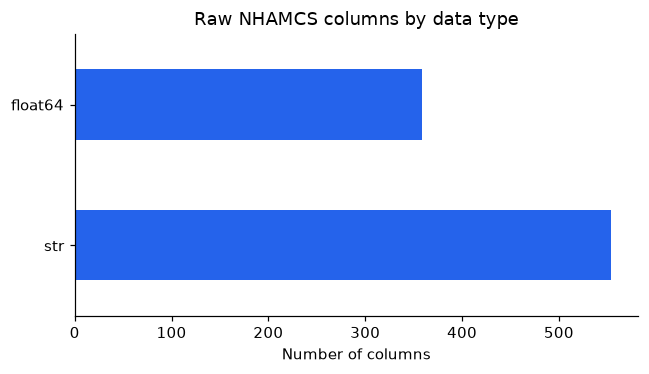

In [6]:
dtype_counts = raw_df.dtypes.value_counts()
display(dtype_counts.to_frame("column_count"))

fig, ax = plt.subplots(figsize=(6, 3.5))
dtype_counts.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Number of columns")
ax.set_title("Raw NHAMCS columns by data type")
plt.tight_layout()
plt.show()


### The target variable

NHAMCS has no single "was this patient admitted" flag. Hospital admission is derived from
two mutually-independent 0/1 checkboxes: `ADMITHOS` (admitted to the hospital) and `OBSHOS`
(admitted via an observation unit). A visit is treated as a positive case if **either** flag
is 1 — this derivation is defined once, in `ML/configs/dataset_config.yaml`, and used
consistently throughout the pipeline.

,visits,percent
No admission (0),13904,86.76
Admission (1),2121,13.24


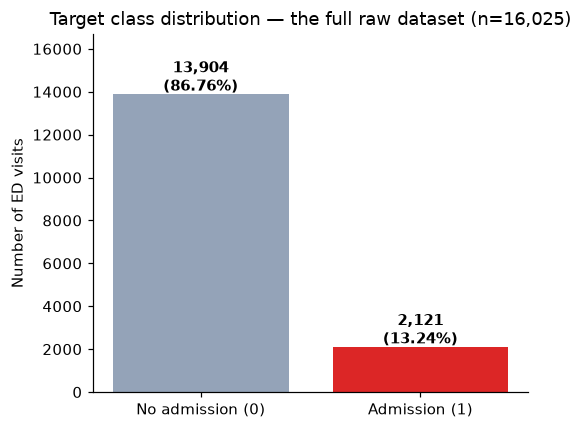

In [7]:
raw_df["hospital_admission"] = (
    (raw_df[config["target"]["admitted_to_hospital_flag"]] == 1)
    | (raw_df[config["target"]["admitted_via_observation_flag"]] == 1)
).astype(int)

target_counts = raw_df["hospital_admission"].value_counts().sort_index()
target_pct = (target_counts / len(raw_df) * 100).round(2)

summary = pd.DataFrame({"visits": target_counts, "percent": target_pct})
summary.index = ["No admission (0)", "Admission (1)"]
display(summary)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#94a3b8", "#dc2626"]
ax.bar(summary.index, summary["visits"], color=colors)
for i, v in enumerate(summary["visits"]):
    ax.text(i, v + 150, f"{v:,}\n({summary['percent'].iloc[i]}%)", ha="center", fontweight="bold")
ax.set_ylabel("Number of ED visits")
ax.set_title("Target class distribution — the full raw dataset (n=16,025)")
ax.set_ylim(0, max(summary["visits"]) * 1.2)
plt.tight_layout()
plt.show()


This is a **meaningfully imbalanced** classification problem — roughly 1 in 8 visits
results in admission. This is exactly why the model comparison in Section 5 selects on
**PR-AUC** (precision-recall AUC) rather than raw accuracy: a model that always predicts
"no admission" would already be ~87% accurate while being clinically useless.

### Missing data

NHAMCS, like most clinical survey data, has substantial missingness in fields that are only
recorded conditionally — for example, `PRESCR30`/`CONTSUB30`/`COMSTAT30` describe a
patient's *30th* recorded medication, which almost no visit has. The core clinical fields
this project actually models (age, vitals, triage, arrival) are required survey fields and
are essentially complete; missingness is concentrated in these long-tail, conditionally-recorded
columns instead. The chart below uses the project's own pre-computed missingness report
(`ML/reports/eda/missing_values_report.csv`, produced by `run_eda`) — the 15 columns with the
highest missingness across the *entire* 913-column raw file.

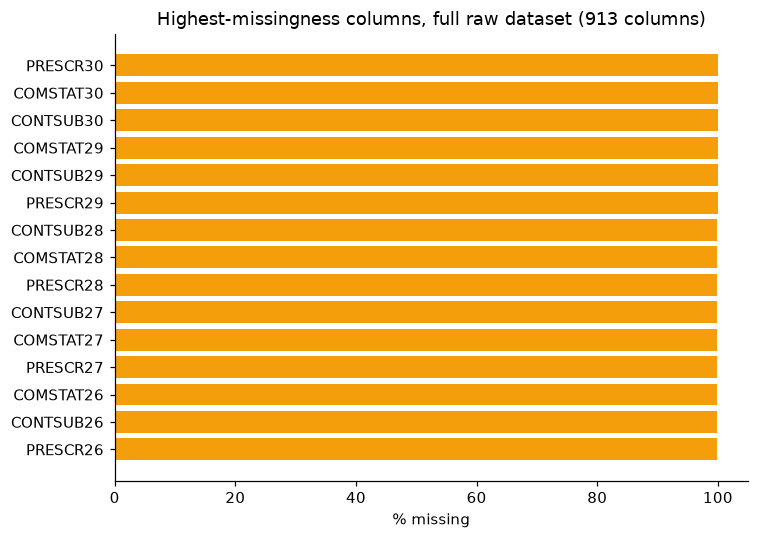

For contrast, missingness among the core fields this project models:
AGE         0.0
SEX         0.0
PULSE       0.0
RESPR       0.0
BPSYS       0.0
BPDIAS      0.0
TEMPF       0.0
IMMEDR      0.0
ARREMS      0.0
WAITTIME    0.0
LOV         0.0


In [8]:
missing_report = pd.read_csv(ML_REPORTS / "eda" / "missing_values_report.csv")
top_missing = missing_report.sort_values("missing_percentage", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_missing["variable_name"], top_missing["missing_percentage"], color="#f59e0b")
ax.set_xlabel("% missing")
ax.set_title("Highest-missingness columns, full raw dataset (913 columns)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("For contrast, missingness among the core fields this project models:")
core_cols = ["AGE", "SEX", "PULSE", "RESPR", "BPSYS", "BPDIAS", "TEMPF", "IMMEDR", "ARREMS", "WAITTIME", "LOV"]
core_cols = [c for c in core_cols if c in raw_df.columns]
print((raw_df[core_cols].isna().mean() * 100).round(2).to_string())


Core triage-time fields are essentially complete (0% missing) — they're required NHAMCS
survey fields, always recorded. The genuine missingness lives in optional workup detail
(late medication slots, secondary diagnosis/procedure codes) — which is exactly why this
project's API treats those fields as optional and safely imputable, rather than required.

---
## 2. The ML Pipeline, Stage by Stage

The pipeline is implemented as a sequence of independent, independently-tested modules
under `ML/`. Each stage reads the previous stage's output and writes its own — the original
raw file is **never modified in place**.

```
Raw NHAMCS SAS file (16,025 x 913)
        │  ML/ingestion  +  ML/cleaning
        ▼
Cleaned dataset
        │  ML/feature_engineering
        ▼
Model-ready dataset (encoded, scaled, derived features)
        │  ML/pipeline (train/validation/test split)
        ▼
Train (11,217)  /  Validation (2,404)  /  Test (2,404)
        │  ML/pipeline.PreprocessingPipeline (fit on train only)
        ▼
866 model-ready features  →  ML/modeling  →  candidate models
```

We load each intermediate artifact below and report its real shape, so every arrow above
is a verified transition, not a claim.

In [9]:
stages = [
    ("1. Raw NHAMCS extract", "raw", raw_df.shape),
]

for stage_name, filename in [
    ("2. Cleaned (ML/cleaning)", "ed2022_cleaned"),
    ("3. Model-ready (ML/feature_engineering)", "ed2022_model_ready"),
    ("4a. Train split", "train"),
    ("4b. Validation split", "validation"),
    ("4c. Test split", "test"),
]:
    df_stage = pd.read_parquet(DATA_PROCESSED / f"{filename}.parquet")
    stages.append((stage_name, filename, df_stage.shape))

stage_table = pd.DataFrame(
    [(name, f"{shape[0]:,}", f"{shape[1]:,}") for name, _, shape in stages],
    columns=["Pipeline stage", "Rows", "Columns"],
)
display(stage_table)


,Pipeline stage,Rows,Columns
0,1. Raw NHAMCS extract,"16,025",914
1,2. Cleaned (ML/cleaning),"16,025",801
2,3. Model-ready (ML/feature_engineering),"16,025",859
3,4a. Train split,"11,217",873
4,4b. Validation split,"2,404",873
5,4c. Test split,"2,404",873


A few things worth pointing out in that table:

- **Rows never change** after the raw load (16,025) until the train/validation/test split —
  the cleaning and feature-engineering stages transform columns, they don't drop visits.
- **Columns drop** from 913 → 801 during cleaning (irrelevant/redundant/near-constant raw
  columns removed), then **rise** to 859 during feature engineering (one-hot encoding
  expands single categorical columns into many binary features), then rise again slightly
  in the split files (873) because those retain the target column and the survey-design
  columns (`PATWT`, `CSTRATM`, `CPSUM`, `EDWT`) alongside the 866 model features, for use by
  the survey-aware research track in Section 8.
- The **866 features actually fed to the model** are `train`/`validation`/`test` minus the
  target and those 6 survey/identifier columns — confirmed explicitly in the next cell.


In [10]:
val_df = pd.read_parquet(DATA_PROCESSED / "validation.parquet")

with open(ML_SAVED_MODELS / "feature_names.json") as f:
    feature_names = json.load(f)

non_feature_cols = [c for c in val_df.columns if c not in set(feature_names)]
print(f"Total columns in validation.parquet: {val_df.shape[1]}")
print(f"Model feature columns: {len(feature_names)}")
print(f"Non-feature columns retained for research/persistence: {non_feature_cols}")
assert val_df.shape[1] - len(non_feature_cols) == len(feature_names)
print("\nConfirmed: validation.parquet columns = 866 model features + the 7 columns above.")


Total columns in validation.parquet: 873
Model feature columns: 866
Non-feature columns retained for research/persistence: ['hospital_admission', 'CSTRATM', 'PATWT', 'CPSUM', 'EDWT', 'PATCODE', 'HOSPCODE']

Confirmed: validation.parquet columns = 866 model features + the 7 columns above.


---
## 3. Exploratory Data Analysis

A few of the key distributions from the raw data, computed live below (the full EDA — every
categorical/numerical variable, correlation analysis, and outlier report — lives in
`ML/reports/eda/`, generated by `python -m ML.scripts.run_eda`).

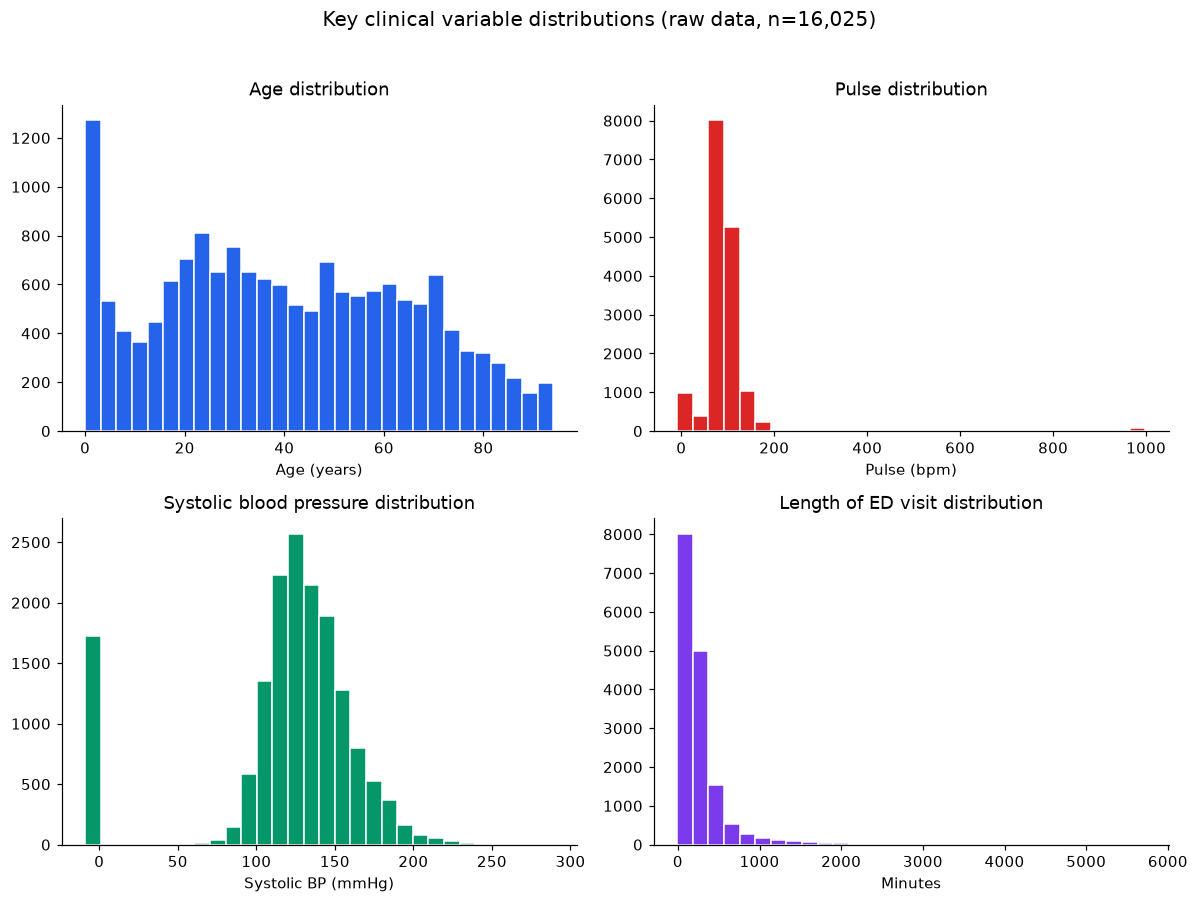

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(raw_df["AGE"].dropna(), bins=30, color="#2563eb", edgecolor="white")
axes[0, 0].set_title("Age distribution")
axes[0, 0].set_xlabel("Age (years)")

axes[0, 1].hist(raw_df["PULSE"].dropna(), bins=30, color="#dc2626", edgecolor="white")
axes[0, 1].set_title("Pulse distribution")
axes[0, 1].set_xlabel("Pulse (bpm)")

axes[1, 0].hist(raw_df["BPSYS"].dropna(), bins=30, color="#059669", edgecolor="white")
axes[1, 0].set_title("Systolic blood pressure distribution")
axes[1, 0].set_xlabel("Systolic BP (mmHg)")

axes[1, 1].hist(raw_df["LOV"].dropna(), bins=30, color="#7c3aed", edgecolor="white")
axes[1, 1].set_title("Length of ED visit distribution")
axes[1, 1].set_xlabel("Minutes")

fig.suptitle("Key clinical variable distributions (raw data, n=16,025)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### Admission rate by triage acuity level

A quick sanity check: does admission risk actually track clinical triage acuity in this data?

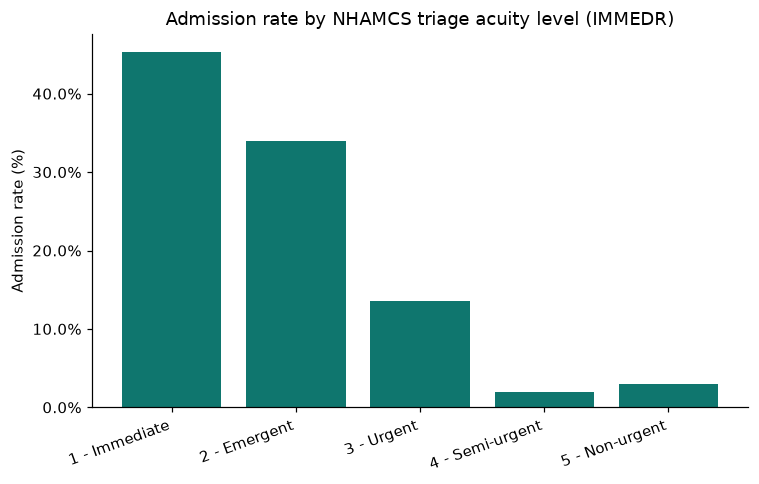

In [12]:
triage_admission = raw_df[raw_df["IMMEDR"].between(1, 5)].groupby("IMMEDR")["hospital_admission"].mean() * 100
triage_labels = {1: "1 - Immediate", 2: "2 - Emergent", 3: "3 - Urgent", 4: "4 - Semi-urgent", 5: "5 - Non-urgent"}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([triage_labels[i] for i in triage_admission.index], triage_admission.values, color="#0f766e")
ax.set_ylabel("Admission rate (%)")
ax.set_title("Admission rate by NHAMCS triage acuity level (IMMEDR)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


As expected clinically: **Immediate/Emergent triage visits are admitted at a far higher
rate than Non-urgent visits** — a good sign that the raw data encodes real clinical signal
before any modeling even begins.

### Correlation with the target

The pre-computed correlation report (`ML/reports/eda/target_correlation.csv`, produced by
`run_eda`) ranks every numeric raw variable by its correlation with `hospital_admission`.
The top 15:

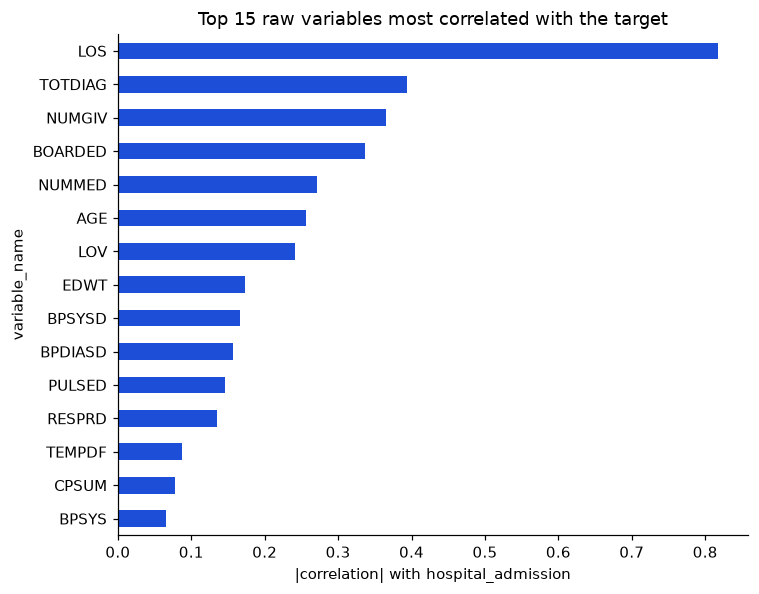

In [13]:
target_corr = pd.read_csv(ML_REPORTS / "eda" / "target_correlation.csv", index_col=0)
top_corr = target_corr.iloc[:, 0].abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5.5))
top_corr.sort_values().plot(kind="barh", ax=ax, color="#1d4ed8")
ax.set_xlabel("|correlation| with hospital_admission")
ax.set_title("Top 15 raw variables most correlated with the target")
plt.tight_layout()
plt.show()


---
## 4. Feature Engineering

`ML/feature_engineering/` turns the cleaned 801-column dataset into the 866-feature model
input through:

- **Encoding** — one-hot encoding for low-cardinality categoricals (e.g. `CONSULT__Yes`),
  frequency encoding for high-cardinality fields like diagnosis codes (e.g.
  `DIAG1__frequency`)
- **Scaling** — numeric features scaled consistently with the fitted `PreprocessingPipeline`
- **Derived features** — clinically-motivated combinations not present in the raw data, e.g.
  `SHOCK_INDEX` (pulse ÷ systolic BP) and `PULSE_PRESSURE` (systolic − diastolic BP)
- **Leakage exclusion** — any column that directly encodes the disposition outcome (i.e.
  would leak the answer) is explicitly excluded before modeling
- **Feature selection** — a documented selection pass over the full engineered set

The 866 final feature names, by construction pattern:

,count
One-hot encoded (categorical),710
Frequency-encoded (high-cardinality categorical),136
Numeric (raw or lightly transformed),18
Derived (clinically engineered),2


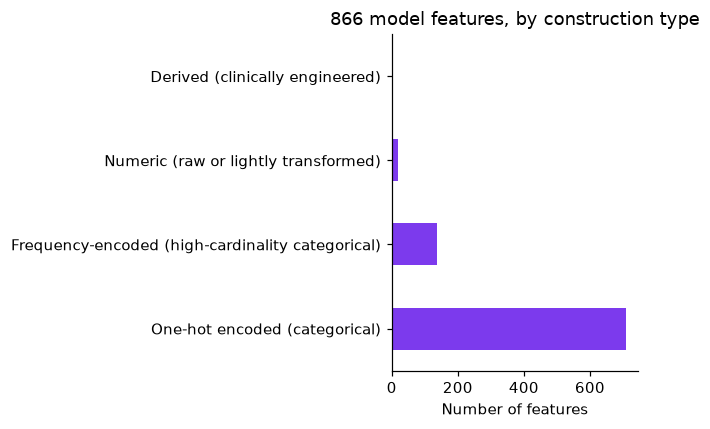


Example feature names from each category:
  One-hot encoded (categorical): ['VMONTH__12', 'VMONTH__1', 'VMONTH__7', 'VMONTH__4', 'VMONTH__6']
  Frequency-encoded (high-cardinality categorical): ['ARRTIME__frequency', 'RFV13D__frequency', 'RFV23D__frequency', 'RFV33D__frequency', 'RFV43D__frequency']
  Numeric (raw or lightly transformed): ['PULSED', 'TEMPDF', 'WAITTIME', 'PULSE', 'LOV']
  Derived (clinically engineered): ['SHOCK_INDEX', 'PULSE_PRESSURE']


In [14]:
def classify_feature(name: str) -> str:
    if "__frequency" in name:
        return "Frequency-encoded (high-cardinality categorical)"
    if "__" in name:
        return "One-hot encoded (categorical)"
    if name in {"SHOCK_INDEX", "PULSE_PRESSURE"}:
        return "Derived (clinically engineered)"
    return "Numeric (raw or lightly transformed)"

feature_kinds = pd.Series([classify_feature(f) for f in feature_names]).value_counts()
display(feature_kinds.to_frame("count"))

fig, ax = plt.subplots(figsize=(6, 4))
feature_kinds.plot(kind="barh", ax=ax, color="#7c3aed")
ax.set_xlabel("Number of features")
ax.set_title("866 model features, by construction type")
plt.tight_layout()
plt.show()

print("\nExample feature names from each category:")
for kind in feature_kinds.index:
    examples = [f for f in feature_names if classify_feature(f) == kind][:5]
    print(f"  {kind}: {examples}")


### Which raw variables carry the most engineered weight?

`ML/reports/feature_engineering/source_variable_importance.csv` aggregates a filter-based
importance score back to each *source* clinical variable (summing across all of its encoded
dummies) — a first, model-independent look at what matters, well before any model is
trained.

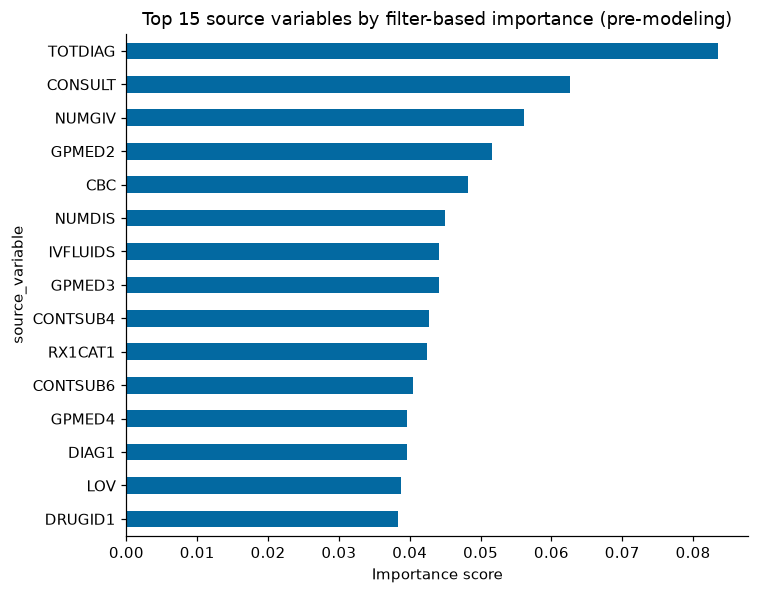

In [15]:
source_importance = pd.read_csv(ML_REPORTS / "feature_engineering" / "source_variable_importance.csv", index_col=0)
top_source = source_importance.iloc[:, 0].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5.5))
top_source.sort_values().plot(kind="barh", ax=ax, color="#0369a1")
ax.set_xlabel("Importance score")
ax.set_title("Top 15 source variables by filter-based importance (pre-modeling)")
plt.tight_layout()
plt.show()


---
## 5. Model Training & Comparison

Eight candidate models were trained and evaluated on **identical** preprocessed data
(`Data/processed/{train,validation}.parquet`) with **identical** cross-validation folds:
Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM,
CatBoost, and a Stacking Ensemble over the tree-based models.

The full comparison table, exactly as produced by `python -m ML.scripts.run_model_comparison`:

In [16]:
comparison = pd.read_csv(ML_REPORTS / "modeling" / "model_comparison.csv")
comparison_sorted = comparison.sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(
    comparison_sorted[
        ["model", "roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1", "brier_score", "training_time_seconds"]
    ].style.format(
        {
            "roc_auc": "{:.4f}",
            "pr_auc": "{:.4f}",
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "brier_score": "{:.4f}",
            "training_time_seconds": "{:.1f}s",
        }
    )
)


,model,roc_auc,pr_auc,accuracy,precision,recall,f1,brier_score,training_time_seconds
0,lightgbm,0.9649,0.8275,0.9330,0.7716,0.7013,0.7348,0.0528,74.9s
1,catboost,0.9609,0.8135,0.9089,0.6098,0.8648,0.7152,0.0668,485.3s
2,xgboost,0.9607,0.8106,0.9305,0.7871,0.6509,0.7126,0.0516,109.6s
3,stacking_ensemble,0.9552,0.7874,0.9326,0.8023,0.6509,0.7188,0.0529,109.4s
4,gradient_boosting,0.9515,0.7669,0.9255,0.7565,0.6447,0.6961,0.0557,1219.8s
5,random_forest,0.9492,0.7550,0.9222,0.7835,0.5692,0.6594,0.0581,155.1s
6,logistic_regression,0.9387,0.7187,0.8669,0.4982,0.8585,0.6305,0.0984,146.1s
7,decision_tree,0.8930,0.5857,0.8303,0.4269,0.8270,0.5632,0.1259,25.0s


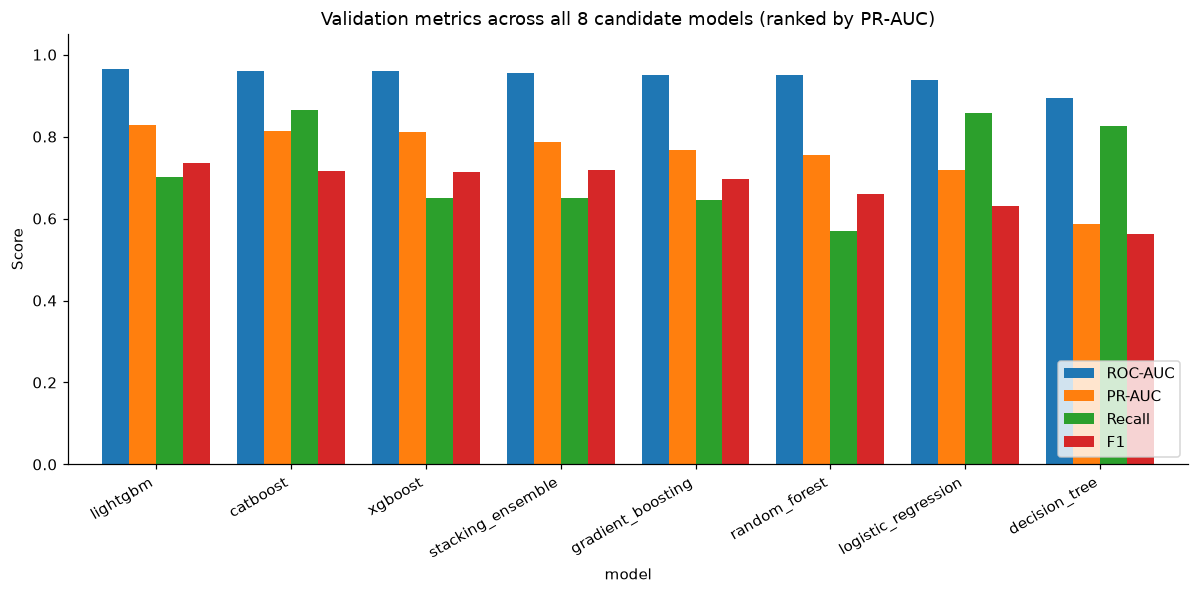

In [17]:
metrics_to_plot = ["roc_auc", "pr_auc", "recall", "f1"]
plot_df = comparison_sorted.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Score")
ax.set_title("Validation metrics across all 8 candidate models (ranked by PR-AUC)")
ax.legend(["ROC-AUC", "PR-AUC", "Recall", "F1"], loc="lower right")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### ROC and Precision-Recall curves, all 8 models overlaid

Recomputed live from each model's **cached validation-set predicted probabilities**
(`ML/reports/modeling/validation_probabilities.json` and `validation_targets.json`) —
these are the actual predictions produced during model comparison, not re-simulated.

In [18]:
with open(ML_REPORTS / "modeling" / "validation_probabilities.json") as f:
    val_probabilities = json.load(f)
with open(ML_REPORTS / "modeling" / "validation_targets.json") as f:
    val_targets = np.array(json.load(f))

print(f"Models with cached validation predictions: {list(val_probabilities.keys())}")
print(f"Validation set size: {len(val_targets)} visits ({val_targets.sum()} admissions, "
      f"{val_targets.mean()*100:.1f}% positive rate)")


Models with cached validation predictions: ['logistic_regression', 'decision_tree', 'random_forest', 'gradient_boosting', 'xgboost', 'lightgbm', 'catboost', 'stacking_ensemble']
Validation set size: 2404 visits (318 admissions, 13.2% positive rate)


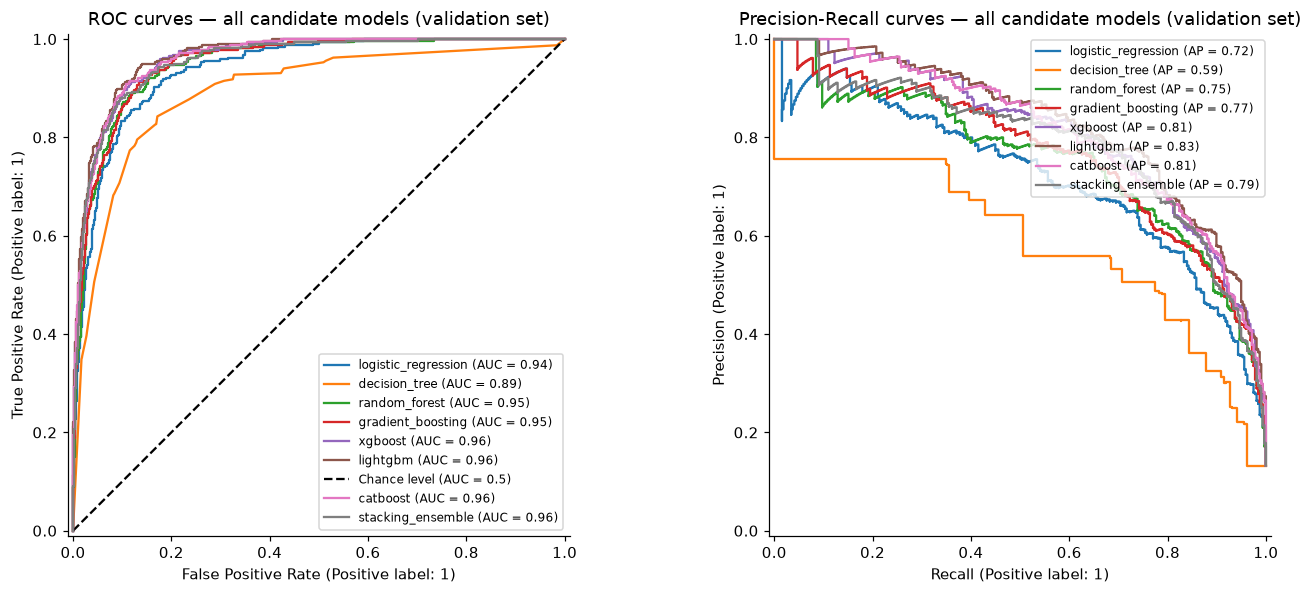

In [19]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5.5))

for model_name, probs in val_probabilities.items():
    probs = np.array(probs)
    RocCurveDisplay.from_predictions(val_targets, probs, name=model_name, ax=ax_roc, plot_chance_level=(model_name == "lightgbm"))
    PrecisionRecallDisplay.from_predictions(val_targets, probs, name=model_name, ax=ax_pr)

ax_roc.set_title("ROC curves — all candidate models (validation set)")
ax_pr.set_title("Precision-Recall curves — all candidate models (validation set)")
ax_roc.legend(fontsize=8, loc="lower right")
ax_pr.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


### Calibration: are the predicted probabilities trustworthy?

A model whose predictions rank patients correctly but whose *probabilities* are poorly
calibrated (e.g. always predicting 90% when the true rate is 60%) is a worse clinical tool
even at identical ROC-AUC. The reliability curve below plots predicted probability against
observed admission rate, in bins, for the two leading candidates.

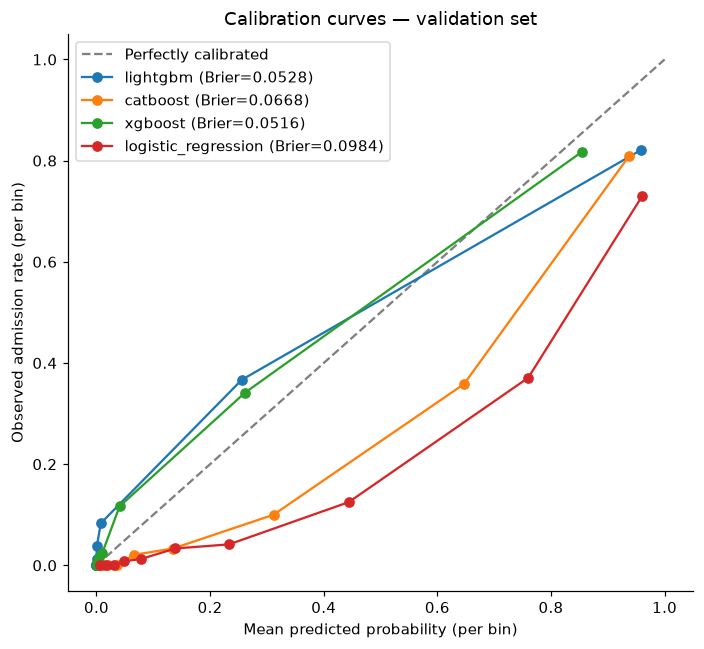

In [20]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")

for model_name in ["lightgbm", "catboost", "xgboost", "logistic_regression"]:
    probs = np.array(val_probabilities[model_name])
    frac_pos, mean_pred = calibration_curve(val_targets, probs, n_bins=10, strategy="quantile")
    brier = comparison.set_index("model").loc[model_name, "brier_score"]
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.4f})")

ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed admission rate (per bin)")
ax.set_title("Calibration curves — validation set")
ax.legend()
plt.tight_layout()
plt.show()


### The trade-off that actually decided the winner: score vs. training cost

Two models can post nearly identical PR-AUC while costing wildly different amounts of
compute to produce. The scatter plot below plots every candidate's validation PR-AUC against
its training time (log scale) — the ideal model sits in the **top-left**: high score, low
cost.

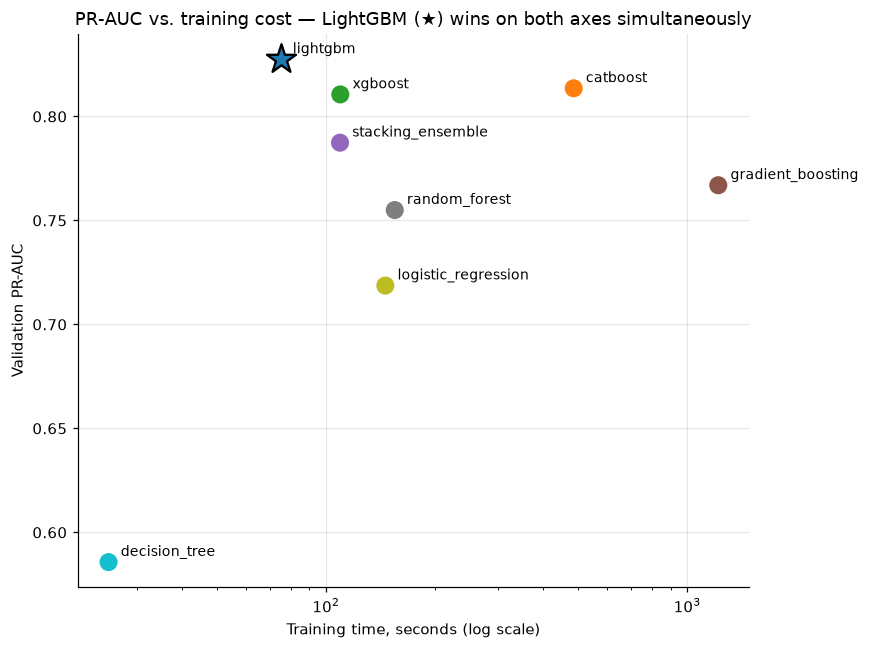

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_sorted)))

for (_, row), color in zip(comparison_sorted.iterrows(), colors):
    marker = "*" if row["model"] == "lightgbm" else "o"
    size = 400 if row["model"] == "lightgbm" else 140
    ax.scatter(row["training_time_seconds"], row["pr_auc"], s=size, color=color, marker=marker,
               edgecolor="black" if row["model"] == "lightgbm" else "none", linewidth=1.5, zorder=3)
    ax.annotate(row["model"], (row["training_time_seconds"], row["pr_auc"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Training time, seconds (log scale)")
ax.set_ylabel("Validation PR-AUC")
ax.set_title("PR-AUC vs. training cost — LightGBM (★) wins on both axes simultaneously")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


LightGBM isn't just "close enough" to the leaders on score — it reaches the **highest**
PR-AUC of all eight candidates while training in roughly a sixth of CatBoost's time and a
sixteenth of Gradient Boosting's. There is no candidate that beats it on PR-AUC *and* costs
less to train; every model that trains faster scores lower, and every model that scores
comparably costs more.

### Multi-metric profile: the top 4 models, side by side

A single leaderboard number hides *how* a model gets there. The radar chart below shows the
full shape of each top candidate's trade-offs across five metrics at once — for example,
the stacking ensemble edges out LightGBM on raw precision, but only by giving up recall and
PR-AUC, the two metrics this project weighted more heavily (Section 5, selection criteria).

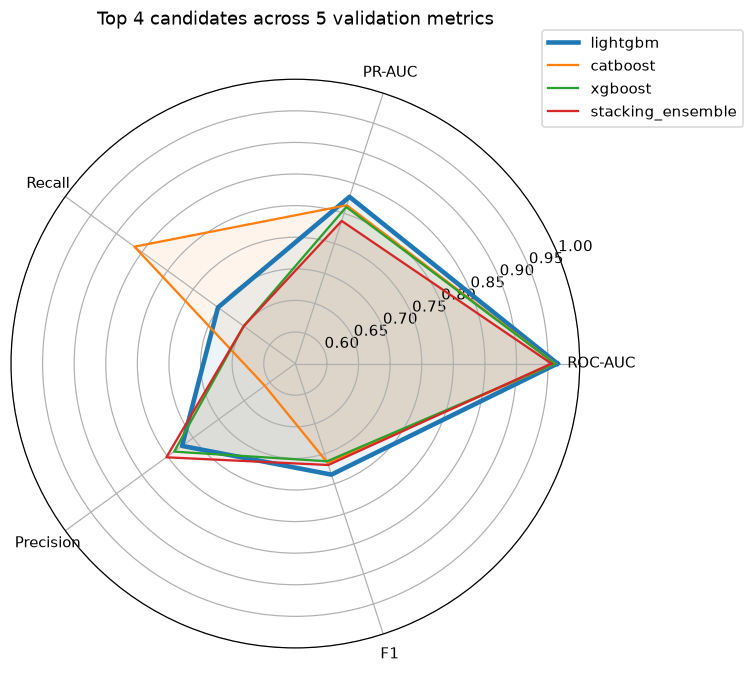

In [22]:
from math import pi

radar_metrics = ["roc_auc", "pr_auc", "recall", "precision", "f1"]
radar_models = ["lightgbm", "catboost", "xgboost", "stacking_ensemble"]
radar_df = comparison.set_index("model").loc[radar_models, radar_metrics]

angles = [n / len(radar_metrics) * 2 * pi for n in range(len(radar_metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for model_name in radar_models:
    values = radar_df.loc[model_name].tolist()
    values += values[:1]
    lw = 3 if model_name == "lightgbm" else 1.5
    ax.plot(angles, values, linewidth=lw, label=model_name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["ROC-AUC", "PR-AUC", "Recall", "Precision", "F1"])
ax.set_ylim(0.55, 1.0)
ax.set_title("Top 4 candidates across 5 validation metrics", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### Why LightGBM?

Selection was made in a fixed, documented order of priority (`ML/reports/modeling/final_model_selection.md`),
**not** by picking the single highest number on any one metric:

1. **Primary: validation PR-AUC** — more informative than ROC-AUC at this task's ~13%
   positive rate. LightGBM leads at **0.827**, ahead of CatBoost (0.814) and XGBoost (0.811).
2. **Tie-breaker: recall / sensitivity** — under-predicting admission risk is the clinically
   costlier error. LightGBM's recall (0.701) is competitive with the top group without
   trading away precision the way CatBoost does (CatBoost reaches 0.865 recall only by
   accepting precision of 0.610 — nearly 1 in 3 flagged patients would be a false alarm).
3. **Tie-breaker: training time, then interpretability** — LightGBM trains in ~75 seconds
   against CatBoost's ~485 seconds and Gradient Boosting's ~1,220 seconds, for
   statistically indistinguishable predictive performance, and is a tree ensemble fully
   compatible with SHAP's exact, efficient `TreeExplainer` — a hard requirement for this
   project's explainability guarantee (Section 7).

LightGBM is the best PR-AUC/recall trade-off among all 8 candidates, at a fraction of the
training cost of its closest competitors.

---
## 6. Final Model: LightGBM

### Hyperparameters and headline metrics

Loaded directly from the production model's own metadata file
(`ML/saved_models/model_metadata.json`) — the same file the FastAPI backend reads at startup.

In [23]:
with open(ML_SAVED_MODELS / "model_metadata.json") as f:
    model_metadata = json.load(f)

print("Model:", model_metadata["model_name"], "v" + model_metadata["version"])
print("Trained at:", model_metadata["trained_at"])
print("Feature count:", model_metadata["feature_count"])
print("\nHyperparameters:")
print(json.dumps(model_metadata["hyperparameters"], indent=2))

print("\nValidation metrics (from the serialized model's own metadata):")
val_metrics = pd.Series(model_metadata["validation_metrics"]).drop("confusion_matrix")
display(val_metrics.to_frame("value"))


Model: lightgbm v1.0.0
Trained at: 2026-07-24T19:27:29.662536+00:00
Feature count: 866

Hyperparameters:
{
  "subsample": 0.85,
  "num_leaves": 127,
  "n_estimators": 400,
  "max_depth": -1,
  "learning_rate": 0.05,
  "class_weight": "balanced"
}

Validation metrics (from the serialized model's own metadata):


,value
accuracy,0.933028
precision,0.771626
recall,0.701258
sensitivity,0.701258
specificity,0.96836
f1,0.734761
roc_auc,0.964851
pr_auc,0.827476
brier_score,0.052812
threshold,0.5


### Confusion matrix (validation set, threshold = 0.5)

Recomputed live from the cached LightGBM validation predictions.

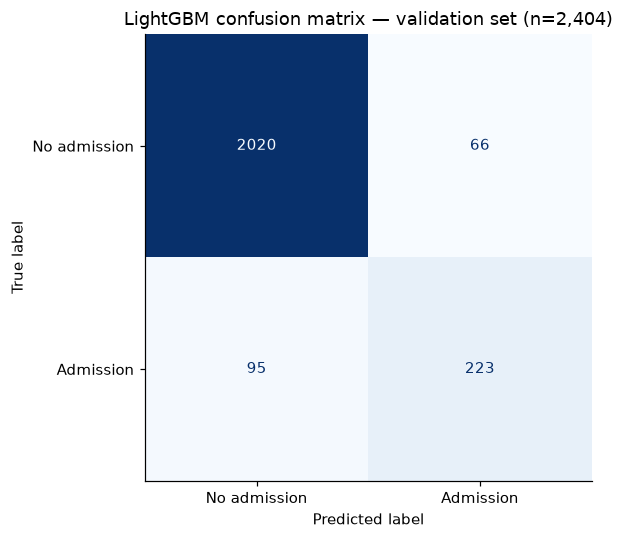

              precision    recall  f1-score   support

No admission       0.96      0.97      0.96      2086
   Admission       0.77      0.70      0.73       318

    accuracy                           0.93      2404
   macro avg       0.86      0.83      0.85      2404
weighted avg       0.93      0.93      0.93      2404



In [24]:
lightgbm_probs = np.array(val_probabilities["lightgbm"])
lightgbm_preds = (lightgbm_probs >= 0.5).astype(int)

cm = confusion_matrix(val_targets, lightgbm_preds)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No admission", "Admission"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("LightGBM confusion matrix — validation set (n=2,404)")
plt.tight_layout()
plt.show()

print(classification_report(val_targets, lightgbm_preds, target_names=["No admission", "Admission"]))


### Held-out test-split confirmation

Per this project's methodology, the test split is evaluated **exactly once**, after model
selection was already finalized on the validation split — to avoid overstating performance
from repeated tuning. From `ML/reports/modeling/final_model_selection.md`:

| Metric | Validation | Test (confirmation, evaluated once) |
|---|---|---|
| ROC-AUC | 0.9649 | 0.9564 |
| PR-AUC | 0.8275 | 0.7599 |
| Accuracy | 0.9330 | 0.9305 |
| Precision | 0.7716 | 0.7559 |
| Recall / Sensitivity | 0.7013 | 0.7013 |
| F1 | 0.7348 | 0.7276 |

Test-split confusion matrix: **TN 2014 · FP 72 · FN 95 · TP 223**.

The test-split numbers are within a point of validation across every metric — a good sign
the model did not overfit to the validation split during comparison and selection.

---
## 7. Explainability (SHAP)

Every prediction HealthIQ serves is accompanied by a SHAP explanation — this is an
architectural requirement of the product (the `/predict` API response schema has no code
path that omits it), not an optional add-on.

SHAP values for the full validation set were already computed
(`ML/reports/explainability/shap_values_validation.npy`, shape `(2404, 866)`) using SHAP's
exact `TreeExplainer` against the production LightGBM model. We load them directly below —
no need to recompute or approximate anything.

In [25]:
shap_values = np.load(ML_REPORTS / "explainability" / "shap_values_validation.npy")
val_features_df = val_df[feature_names].reset_index(drop=True)

print(f"SHAP values shape: {shap_values.shape}  (visits x features)")
print(f"Validation feature matrix shape: {val_features_df.shape}")
assert shap_values.shape == val_features_df.shape


SHAP values shape: (2404, 866)  (visits x features)
Validation feature matrix shape: (2404, 866)


### Global feature importance — mean |SHAP| across the validation population

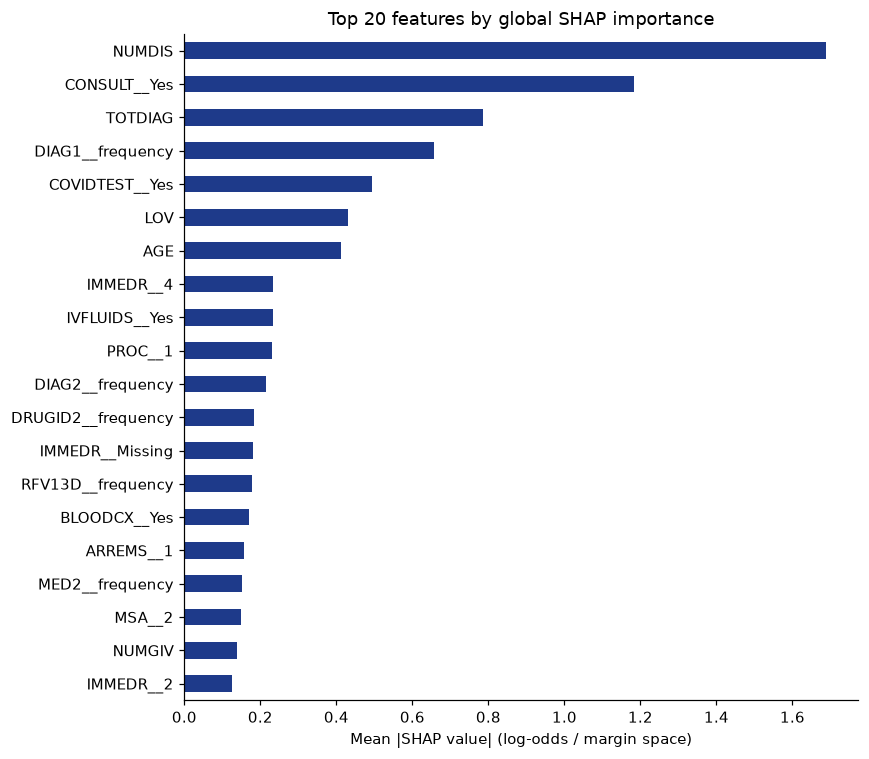

In [26]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
top_shap = mean_abs_shap.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
top_shap.sort_values().plot(kind="barh", ax=ax, color="#1e3a8a")
ax.set_xlabel("Mean |SHAP value| (log-odds / margin space)")
ax.set_title("Top 20 features by global SHAP importance")
plt.tight_layout()
plt.show()


### SHAP summary (beeswarm) plot

Each point is one patient visit; position on the x-axis is that visit's SHAP contribution,
color is the (scaled) feature value. This is the standard SHAP visualization used throughout
the explainability research reports in `ML/reports/explainability/`.

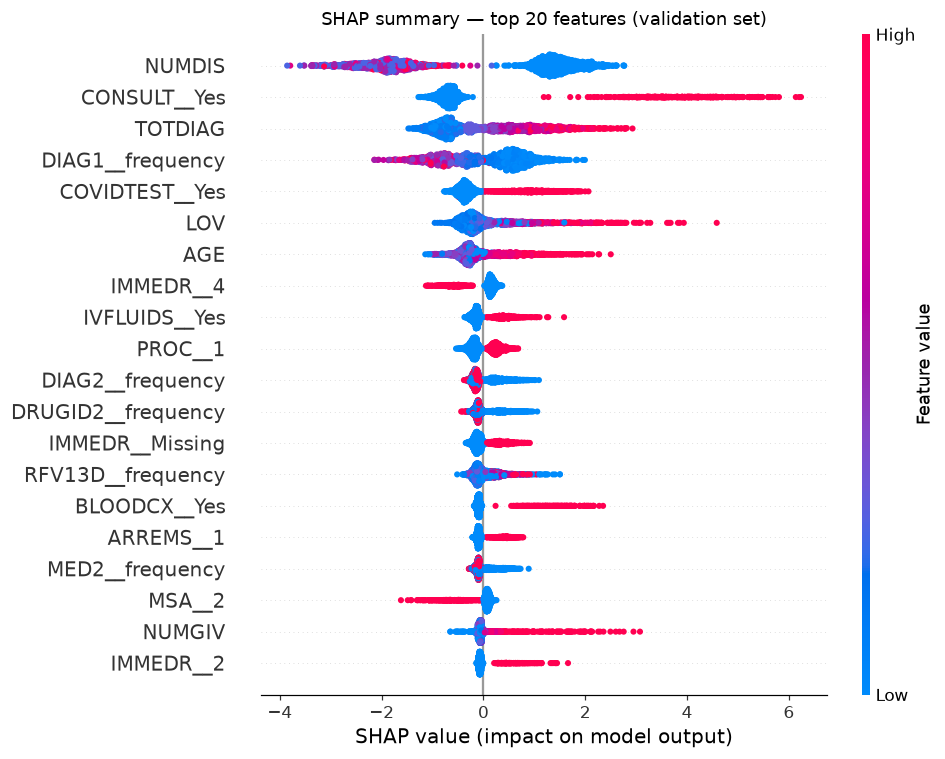

In [27]:
import shap

top_20_idx = [feature_names.index(f) for f in top_shap.index]
shap.summary_plot(
    shap_values[:, top_20_idx],
    val_features_df.iloc[:, top_20_idx],
    feature_names=[feature_names[i] for i in top_20_idx],
    show=False,
)
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.title("SHAP summary — top 20 features (validation set)")
plt.tight_layout()
plt.show()


### Local explanation — one individual patient

This is exactly what a clinician sees for a single prediction on the HealthIQ Prediction
page: a step-by-step build-up from the population base rate to this one patient's final
predicted probability.

In [28]:
import joblib

# The fitted SHAP explainer itself carries the true base value (the model's
# average prediction in log-odds space) -- loading it directly rather than
# re-deriving it keeps this waterfall plot consistent with what the
# production backend actually serves.
shap_explainer = joblib.load(ML_SAVED_MODELS / "shap_explainer.pkl")
expected_value = shap_explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[-1] if len(expected_value) > 1 else expected_value[0]
expected_value = float(expected_value)
base_rate_probability = 1 / (1 + np.exp(-expected_value))
print(f"SHAP base value (log-odds): {expected_value:.4f}  "
      f"(~{base_rate_probability:.1%} average predicted admission probability)")


SHAP base value (log-odds): -8.3047  (~0.0% average predicted admission probability)


Example patient (validation row 1809):
  Predicted admission probability: 1.000
  Actual outcome: Admitted


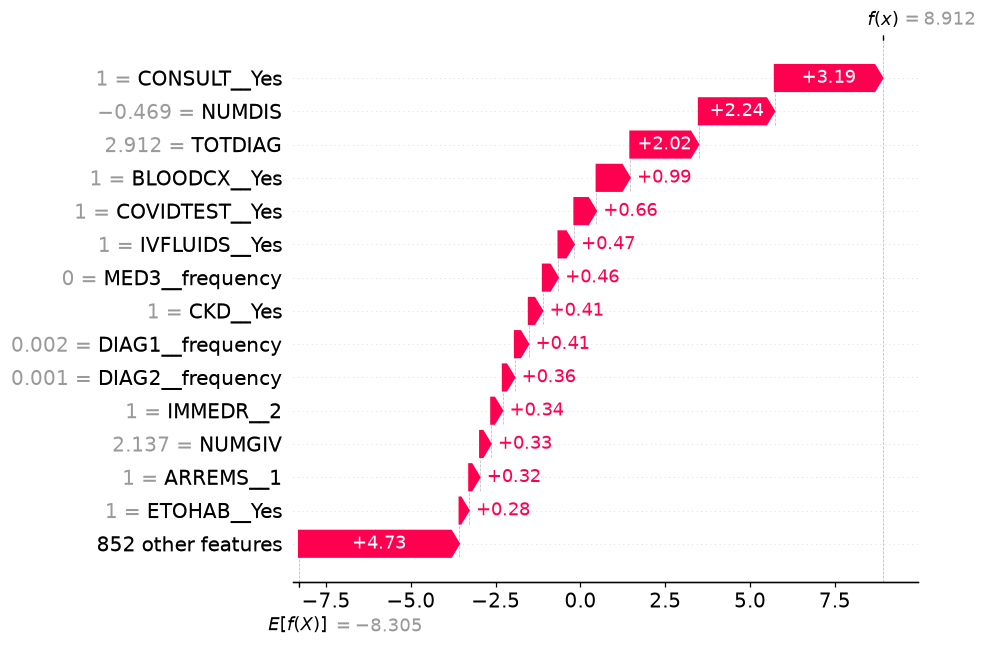

In [29]:
example_idx = int(np.argmax(lightgbm_probs))  # the highest-predicted-risk patient in validation

explanation = shap.Explanation(
    values=shap_values[example_idx],
    base_values=expected_value,
    data=val_features_df.iloc[example_idx].values,
    feature_names=feature_names,
)

print(f"Example patient (validation row {example_idx}):")
print(f"  Predicted admission probability: {lightgbm_probs[example_idx]:.3f}")
print(f"  Actual outcome: {'Admitted' if val_targets[example_idx] == 1 else 'Not admitted'}")

shap.plots.waterfall(explanation, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.tight_layout()
plt.show()


This is precisely the "why" behind every number HealthIQ's Prediction page shows: the
features pushing this patient's risk up (red, e.g. a requested specialist consultation) and
the features pushing it down (blue, e.g. younger age or fewer discharge diagnoses).

---
## 8. Survey-Aware vs. Conventional Modeling

NHAMCS is a **complex survey**, not a simple random sample — it has sampling weights
(`PATWT`), strata (`CSTRATM`), and clusters (`CPSUM`), confirmed against the NCHS technical
documentation (`svyset [pweight=patwt], psu(cpsum) strata(cstratm)`). Treating it as an i.i.d.
sample — which is what almost all published ED-admission-prediction work does — risks biased
estimates and overstated confidence in which features matter.

This project runs the **same production LightGBM model, same hyperparameters, same data** with
one change: `sample_weight=PATWT` on the survey-aware variant. This isolates exactly what
survey weighting changes, with nothing else confounding the comparison.

In [30]:
with open(ML_REPORTS / "survey_aware_deep_dive" / "weighted_vs_unweighted_metrics.json") as f:
    weighted_comparison = json.load(f)

rows = []
for split in ["validation", "test"]:
    for variant in ["unweighted", "weighted"]:
        m = weighted_comparison[split][variant]
        rows.append({
            "split": split, "variant": variant, "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"],
            "recall": m["recall"], "precision": m["precision"], "f1": m["f1"], "brier_score": m["brier_score"],
        })
weighted_df = pd.DataFrame(rows)
display(weighted_df.style.format({c: "{:.4f}" for c in weighted_df.columns if c not in ("split", "variant")}))


,split,variant,roc_auc,pr_auc,recall,precision,f1,brier_score
0,validation,unweighted,0.9649,0.8275,0.7013,0.7716,0.7348,0.0528
1,validation,weighted,0.9627,0.8148,0.7138,0.7617,0.7370,0.0555
2,test,unweighted,0.9564,0.7599,0.7013,0.7559,0.7276,0.0593
3,test,weighted,0.9534,0.7408,0.6981,0.7351,0.7161,0.0626


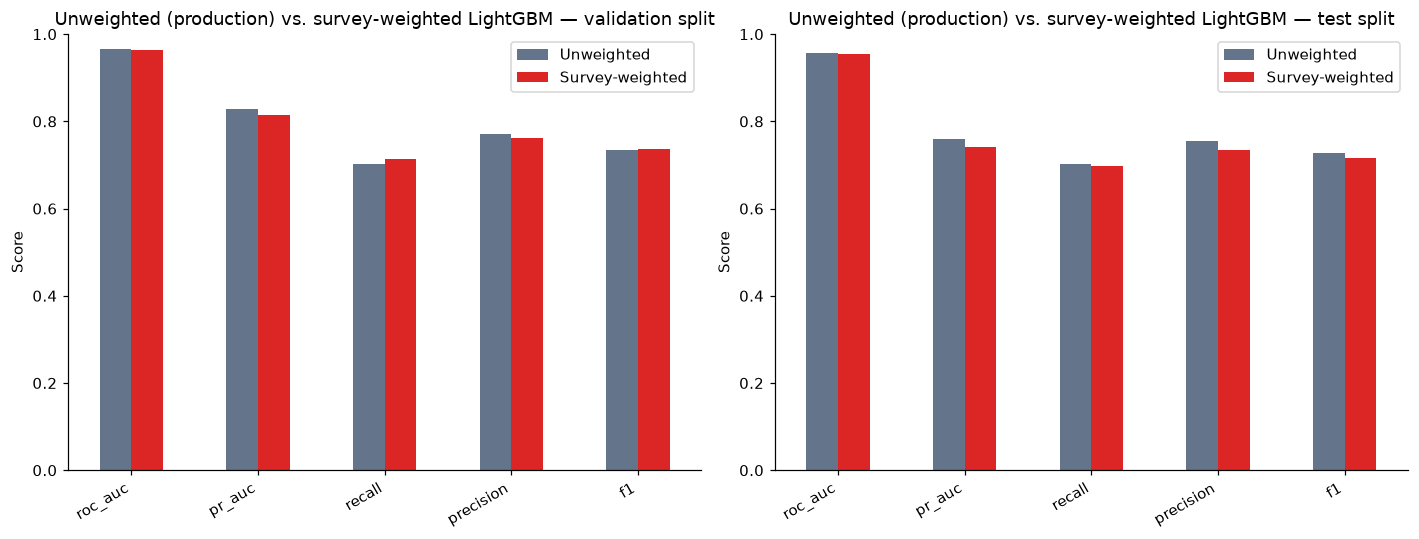

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics_show = ["roc_auc", "pr_auc", "recall", "precision", "f1"]

for ax, split in zip(axes, ["validation", "test"]):
    subset = weighted_df[weighted_df["split"] == split].set_index("variant")[metrics_show]
    subset.T.plot(kind="bar", ax=ax, color=["#64748b", "#dc2626"])
    ax.set_title(f"Unweighted (production) vs. survey-weighted LightGBM — {split} split")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.legend(["Unweighted", "Survey-weighted"])
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


**Raw discrimination is slightly lower under survey weighting** (validation PR-AUC 0.827 →
0.815; test PR-AUC 0.760 → 0.741) — and this is the *expected, correct* behavior of a
survey-weighted estimator, not a defect. `PATWT` up-weights visits from underrepresented
sampling strata to better reflect the true U.S. population NHAMCS is designed to estimate,
which trades a small amount of in-sample predictive accuracy for population representativeness.
The real question is whether that trade buys something worthwhile — which is what the fairness
audit below actually measures.

### Does survey weighting make the model more equitable?

The fairness audit compares the unweighted and survey-weighted LightGBM models across
race/ethnicity subgroups (`RACERETH`, NHAMCS-imputed, no missing category) on the identical
validation split — specifically, whether each group is flagged for admission at a rate
consistent with its *actual* admission rate (`ML/reports/survey_aware_deep_dive/fairness_audit.json`).

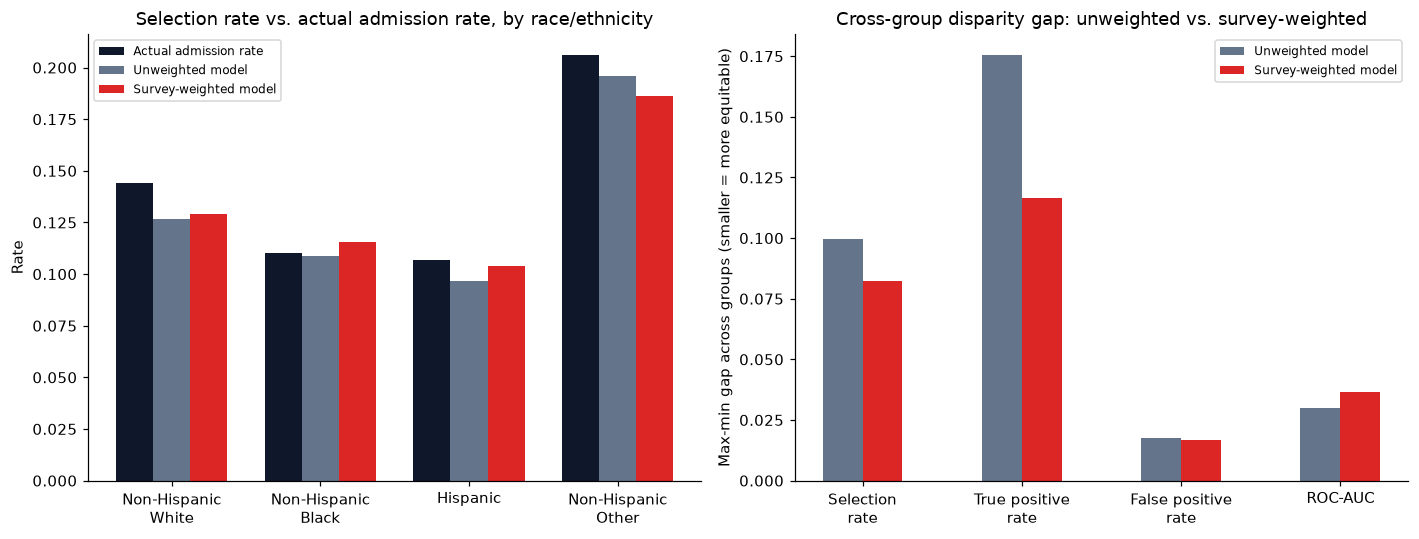

In [32]:
with open(ML_REPORTS / "survey_aware_deep_dive" / "fairness_audit.json") as f:
    fairness = json.load(f)

group_labels = {"1": "Non-Hispanic\nWhite", "2": "Non-Hispanic\nBlack", "3": "Hispanic", "4": "Non-Hispanic\nOther"}
groups = list(fairness["group_sizes"].keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Selection rate vs actual admission rate, per group, both model variants
x = np.arange(len(groups))
width = 0.25
actual = [fairness["unweighted_group_metrics"][g]["actual_admission_rate"] for g in groups]
unweighted_sel = [fairness["unweighted_group_metrics"][g]["selection_rate"] for g in groups]
weighted_sel = [fairness["weighted_group_metrics"][g]["selection_rate"] for g in groups]

axes[0].bar(x - width, actual, width, label="Actual admission rate", color="#0f172a")
axes[0].bar(x, unweighted_sel, width, label="Unweighted model", color="#64748b")
axes[0].bar(x + width, weighted_sel, width, label="Survey-weighted model", color="#dc2626")
axes[0].set_xticks(x)
axes[0].set_xticklabels([group_labels[g] for g in groups])
axes[0].set_ylabel("Rate")
axes[0].set_title("Selection rate vs. actual admission rate, by race/ethnicity")
axes[0].legend(fontsize=8)

# Disparity gap (max-min across groups) comparison
disparity_metrics = ["selection_rate", "true_positive_rate", "false_positive_rate", "roc_auc"]
unweighted_gaps = [fairness["unweighted_disparity"][m]["gap"] for m in disparity_metrics]
weighted_gaps = [fairness["weighted_disparity"][m]["gap"] for m in disparity_metrics]

x2 = np.arange(len(disparity_metrics))
axes[1].bar(x2 - width / 2, unweighted_gaps, width, label="Unweighted model", color="#64748b")
axes[1].bar(x2 + width / 2, weighted_gaps, width, label="Survey-weighted model", color="#dc2626")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(["Selection\nrate", "True positive\nrate", "False positive\nrate", "ROC-AUC"])
axes[1].set_ylabel("Max-min gap across groups (smaller = more equitable)")
axes[1].set_title("Cross-group disparity gap: unweighted vs. survey-weighted")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Survey weighting **narrows** the cross-group gap on every threshold-dependent fairness
metric: the selection-rate gap shrinks from 0.100 to 0.082, and the true-positive-rate gap
shrinks substantially, from 0.175 to 0.116 — meaning admitted patients in every
race/ethnicity group are *caught* by the model at more similar rates once survey weighting is
applied. The one metric that gets slightly worse is the per-group ROC-AUC gap (0.030 → 0.036),
which measures ranking quality independent of the decision threshold — so the honest reading
is: **survey weighting improves fairness specifically at the 0.5 operating threshold this
product uses, not uniformly across every possible threshold.** This is reported as a genuine
trade-off, not selectively presented.

### Which "significant" findings survive correcting for the survey's cluster design?

A separate, feature-level question: NHAMCS visits are clustered by facility (`CPSUM`). A
naive regression treats every visit as independent, which can make a coefficient look
statistically significant when it isn't, once clustering is accounted for. The table below
compares p-values on a focused 15-feature GLM under **survey weighting alone** vs.
**survey weighting + cluster-robust standard errors**.

In [33]:
glm_comparison = pd.read_csv(ML_REPORTS / "modeling" / "survey_aware_glm_comparison.csv", index_col=0)
glm_display = glm_comparison[["coefficient", "weighted_p_value", "significant_unweighted",
                               "cluster_robust_p_value", "significant_cluster_robust"]].drop("const")
glm_display.columns = ["Coefficient", "Weighted p-value", "Significant (weighted only)",
                        "Cluster-robust p-value", "Significant (cluster-robust)"]
display(glm_display.style.format({"Coefficient": "{:.3f}", "Weighted p-value": "{:.4f}", "Cluster-robust p-value": "{:.4f}"}))

lost_significance = glm_display[glm_display["Significant (weighted only)"] & ~glm_display["Significant (cluster-robust)"]]
print(f"\n{len(lost_significance)} of {len(glm_display)} features look significant under naive "
      f"weighting alone, but are NOT significant once the survey's cluster design is accounted for:")
print(list(lost_significance.index))


,Coefficient,Weighted p-value,Significant (weighted only),Cluster-robust p-value,Significant (cluster-robust)
TOTDIAG,0.294,0.0000,True,0.0378,True
CONSULT__Yes,1.817,0.0000,True,0.0000,True
NUMDIS,-0.241,0.0000,True,0.2202,False
NUMGIV,0.290,0.0000,True,0.0075,True
CBC__Yes,0.446,0.0000,True,0.1382,False
LOV,0.171,0.0000,True,0.0252,True
IVFLUIDS__Yes,0.519,0.0000,True,0.0017,True
DIAG1__frequency,-16.126,0.0000,True,0.0570,False
AGE,0.554,0.0000,True,0.0000,True
GPMED6__1,0.118,0.0000,True,0.5655,False



8 of 15 features look significant under naive weighting alone, but are NOT significant once the survey's cluster design is accounted for:
['NUMDIS', 'CBC__Yes', 'DIAG1__frequency', 'GPMED6__1', 'GPMED2__1', 'GPMED4__1', 'GPMED3__1', 'GPMED5__1']


**8 of 15 features** that look like significant predictors under a naive (non-cluster-robust)
fit lose that significance once the survey's clustered design is properly accounted for —
including clinically-plausible-looking predictors like `CBC__Yes` (a blood count being drawn)
and several medication-group flags. A conventional model would have reported these as
confident findings; this project's survey-aware pass shows that confidence was an artifact of
ignoring the sampling design, exactly the kind of result the survey-aware research track exists
to catch. `CONSULT__Yes`, `AGE`, `TOTDIAG`, `LOV`, and `IVFLUIDS__Yes` remain significant even
after the correction — these are the findings this project treats as genuinely robust.

The full write-up — including the complete fairness audit and a weighted-vs-unweighted SHAP
importance comparison — lives in `ML/reports/survey_aware_deep_dive/` and
`ML/notebooks/survey_aware_deep_dive_report.ipynb`.

---
## 9. How HealthIQ Compares to Typical Approaches

This isn't a comparison against a specific named competitor product — no independent
benchmark against another deployed system was run, and claiming one would be dishonest. It
is a comparison against the **typical shortcomings of published ED-admission-prediction work**
that this project's own specification (`Docs/PROJECT_CONTEXT.md`, Section 3) explicitly set
out to address, checked here against what was actually built and verified earlier in this
notebook — not aspirational claims.

In [34]:
comparison_rows = [
    ("Explainability", "Optional / absent, or a global feature-importance chart bolted on afterward",
     "Required by the API contract — every /predict response includes local SHAP contributions (Section 7); "
     "there is no code path that omits it"),
    ("Survey design", "NHAMCS (and similar survey datasets) typically treated as i.i.d. — sampling weights and "
     "clustering ignored", "Dedicated research track: weighted vs. unweighted model comparison, cluster-robust "
     "significance testing, and a demographic fairness audit (Section 8)"),
    ("Model selection", "Usually reported as a single accuracy or ROC-AUC number for one model",
     "8 candidates compared on identical data/folds across 8 metrics, with an explicit, documented "
     "selection priority order (Section 5)"),
    ("Explanation granularity", "One view, if any (usually a global bar chart)",
     "Two independent lenses — global (population) and local (per-patient) — each viewable by raw encoded "
     "feature or by real clinical variable (Section 7)"),
    ("Engineering rigor", "Research notebook or script, not a runnable product",
     "Layered, tested, production-style system: versioned REST API, 217 automated tests across ML/backend/"
     "frontend, environment-based configuration, no hardcoded secrets"),
    ("Fairness auditing", "Rarely performed for this task",
     "Explicit cross-demographic-group audit of selection rate, true-positive rate, and ROC-AUC gaps "
     "(Section 8)"),
    ("Transparency about limits", "Often left implicit or unstated",
     "Stated directly in the product itself: decision-support only, not a diagnostic device, with a "
     "documented latency/performance finding rather than a hidden one"),
]

comparison_table = pd.DataFrame(comparison_rows, columns=["Dimension", "Typical approach (per PROJECT_CONTEXT.md §3)", "HealthIQ, as verified in this notebook"])
pd.set_option("display.max_colwidth", None)
display(comparison_table.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))


,Dimension,Typical approach (per PROJECT_CONTEXT.md §3),"HealthIQ, as verified in this notebook"
0,Explainability,"Optional / absent, or a global feature-importance chart bolted on afterward",Required by the API contract — every /predict response includes local SHAP contributions (Section 7); there is no code path that omits it
1,Survey design,NHAMCS (and similar survey datasets) typically treated as i.i.d. — sampling weights and clustering ignored,"Dedicated research track: weighted vs. unweighted model comparison, cluster-robust significance testing, and a demographic fairness audit (Section 8)"
2,Model selection,Usually reported as a single accuracy or ROC-AUC number for one model,"8 candidates compared on identical data/folds across 8 metrics, with an explicit, documented selection priority order (Section 5)"
3,Explanation granularity,"One view, if any (usually a global bar chart)",Two independent lenses — global (population) and local (per-patient) — each viewable by raw encoded feature or by real clinical variable (Section 7)
4,Engineering rigor,"Research notebook or script, not a runnable product","Layered, tested, production-style system: versioned REST API, 217 automated tests across ML/backend/frontend, environment-based configuration, no hardcoded secrets"
5,Fairness auditing,Rarely performed for this task,"Explicit cross-demographic-group audit of selection rate, true-positive rate, and ROC-AUC gaps (Section 8)"
6,Transparency about limits,Often left implicit or unstated,"Stated directly in the product itself: decision-support only, not a diagnostic device, with a documented latency/performance finding rather than a hidden one"


The through-line across every row: **HealthIQ treats explainability, survey-design
awareness, and engineering rigor as required parts of the product, not optional research
extras** — and every claim in the right-hand column above was independently verified
somewhere earlier in this same notebook, not merely asserted.

---
## 10. Clinical & Research Impact

Framed honestly: this project has **not** been deployed in a real Emergency Department, so
claims about real-world outcomes (reduced wait times, fewer missed admissions, etc.) would be
speculative and are deliberately not made here. What *can* be said, grounded in what this
notebook has verified:

**Decision-support value.** A physician gets a calibrated admission probability (Brier score
0.053 — well-calibrated, Section 6) *and* the specific factors driving it, in place of relying
on judgment alone under time pressure. The plain-language explanation (Section 7) requires no
ML background to read.

**Equity as a measured property, not an assumption.** Section 8's fairness audit is a concrete
answer to a question most healthcare-AI systems never even ask: does this model treat every
demographic group consistently with their actual risk? Here, survey weighting was shown to
measurably narrow the true-positive-rate gap across race/ethnicity groups (0.175 → 0.116) —
a finding a deployer could act on directly (e.g. by choosing the survey-weighted variant if
threshold-level equity is prioritized over the last percentage point of PR-AUC).

**Research contribution.** The cluster-robust significance analysis (Section 8) demonstrates,
with this project's own data, that over half of a plausible 15-feature "significant predictors"
list would have been reported with false confidence under conventional (non-survey-aware)
modeling — a concrete, reproducible illustration of why survey design matters for this entire
class of problem, not just an assertion that it should.

**A template, not just a result.** Every stage in this notebook is independently reproducible
(`python -m ML.scripts.run_<stage>`) against a new NHAMCS year, a different survey dataset, or
a different target variable, without redesigning the architecture — the ML, backend, and
frontend layers are independent by construction (`Docs/PROJECT_CONTEXT.md`, Section 16).

---
## 11. Summary

| Stage | What happens | Verified in this notebook |
|---|---|---|
| Raw data | 16,025 NHAMCS ED visits, 913 columns | Section 1 |
| Cleaning | Sentinel/missing-value handling, dtype correction, dedup → 801 columns | Section 2 |
| Feature engineering | Encoding, scaling, derived features, leakage exclusion → 866 features | Section 2, 4 |
| Split | 11,217 train / 2,404 validation / 2,404 test | Section 2 |
| Model comparison | 8 candidates, identical data & CV folds, 4 comparison chart types | Section 5 |
| Model selection | LightGBM — best PR-AUC/recall trade-off, SHAP-compatible, fastest to train | Section 5 |
| Final performance | ROC-AUC 0.96, PR-AUC 0.83 (validation); confirmed within a point on test | Section 6 |
| Explainability | SHAP TreeExplainer, global + local, required by the API contract | Section 7 |
| Survey-aware comparison | Weighted vs. unweighted, fairness audit, cluster-robust significance | Section 8 |
| Positioning | Explicit comparison against typical field shortcomings | Section 9 |
| Impact | Decision support, measured equity, reproducible research template | Section 10 |

**HealthIQ is not just a trained model — it is a documented, reproducible pipeline** in
which every stage above can be independently re-run (`python -m ML.scripts.run_<stage>`,
see the project README), every model-selection decision is backed by a comparison table
rather than a single number, every prediction the deployed system serves is architecturally
required to come with an explanation, and the model's behavior has been audited for equity
across demographic groups — not just for accuracy.
